In [1]:
# Modules
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots

plt.style.use('science')
cmap = mcolors.LinearSegmentedColormap.from_list("", ["blue","blueviolet", "mediumorchid","deeppink","red"])
norm = mcolors.Normalize(vmin=4, vmax=8)
eq_temp = 1/(1+(100/np.pi-1)*4172.4/1836.0)

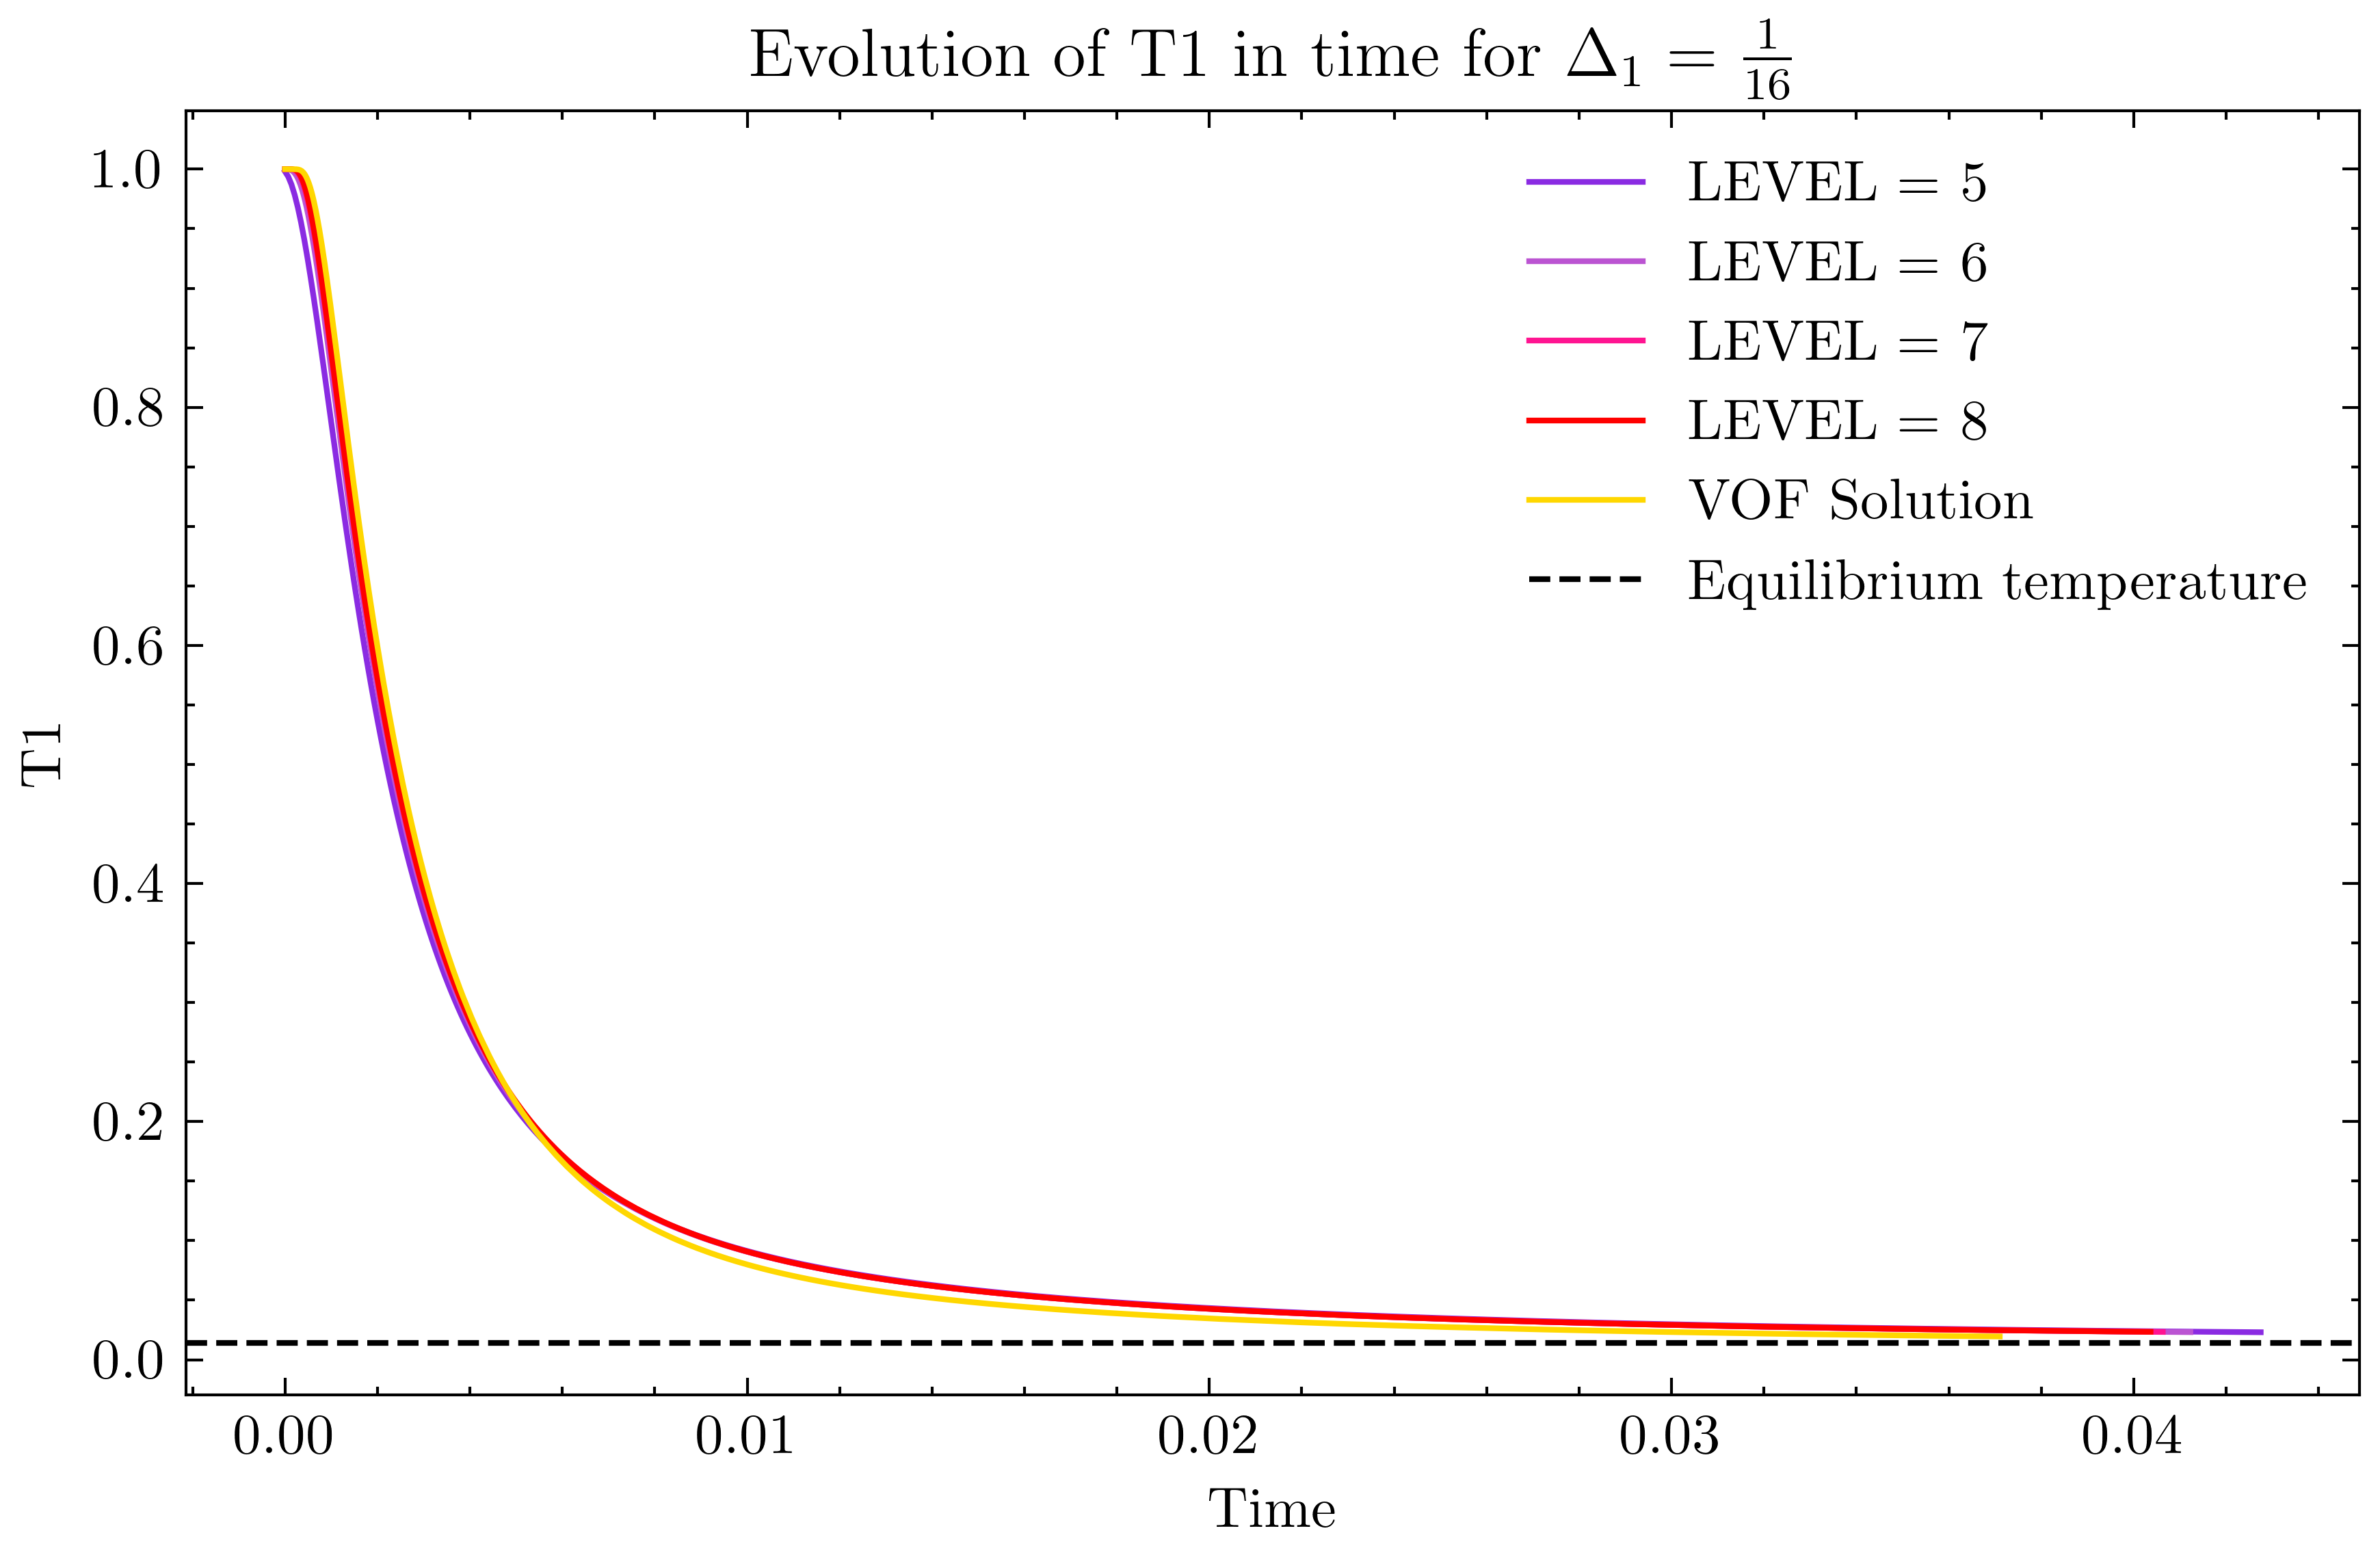

In [2]:
# We plot the graph of  evolution of enthalpy in time
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
ax.set_xlabel("Time")
ax.set_ylabel("T1")
ax.set_title(r"Evolution of T1 in time for $\Delta_1 = \frac{1}{16}$")

for i in range(5,9):
    data = np.loadtxt(f"deltax=16/LEVEL_{i}/data.vof")
    time = data[:,0]
    T1 = data[:,1]
    graph_color = cmap(norm(i))
    ax.plot(time, T1, color = graph_color, label = f"LEVEL = {i}")

data_vof = np.loadtxt("/home/bilal/basilisk/LEVEL_convergence/temp_measure/null_velocity/temp_diff_method/output/LEVEL_9/data.vof")
time_vof = data_vof[:,0]
T1_vof = data_vof[:,1]
T2_vof = data_vof[:,2]
ax.plot(time_vof,T1_vof, color = "gold", label = "VOF Solution")


plt.axhline(y=eq_temp, color='k', linestyle='--', label = "Equilibrium temperature")
ax.legend()
plt.tight_layout()
plt.savefig("Figures/Error of T1 in time for deltax=16.png",dpi=600)
plt.show()

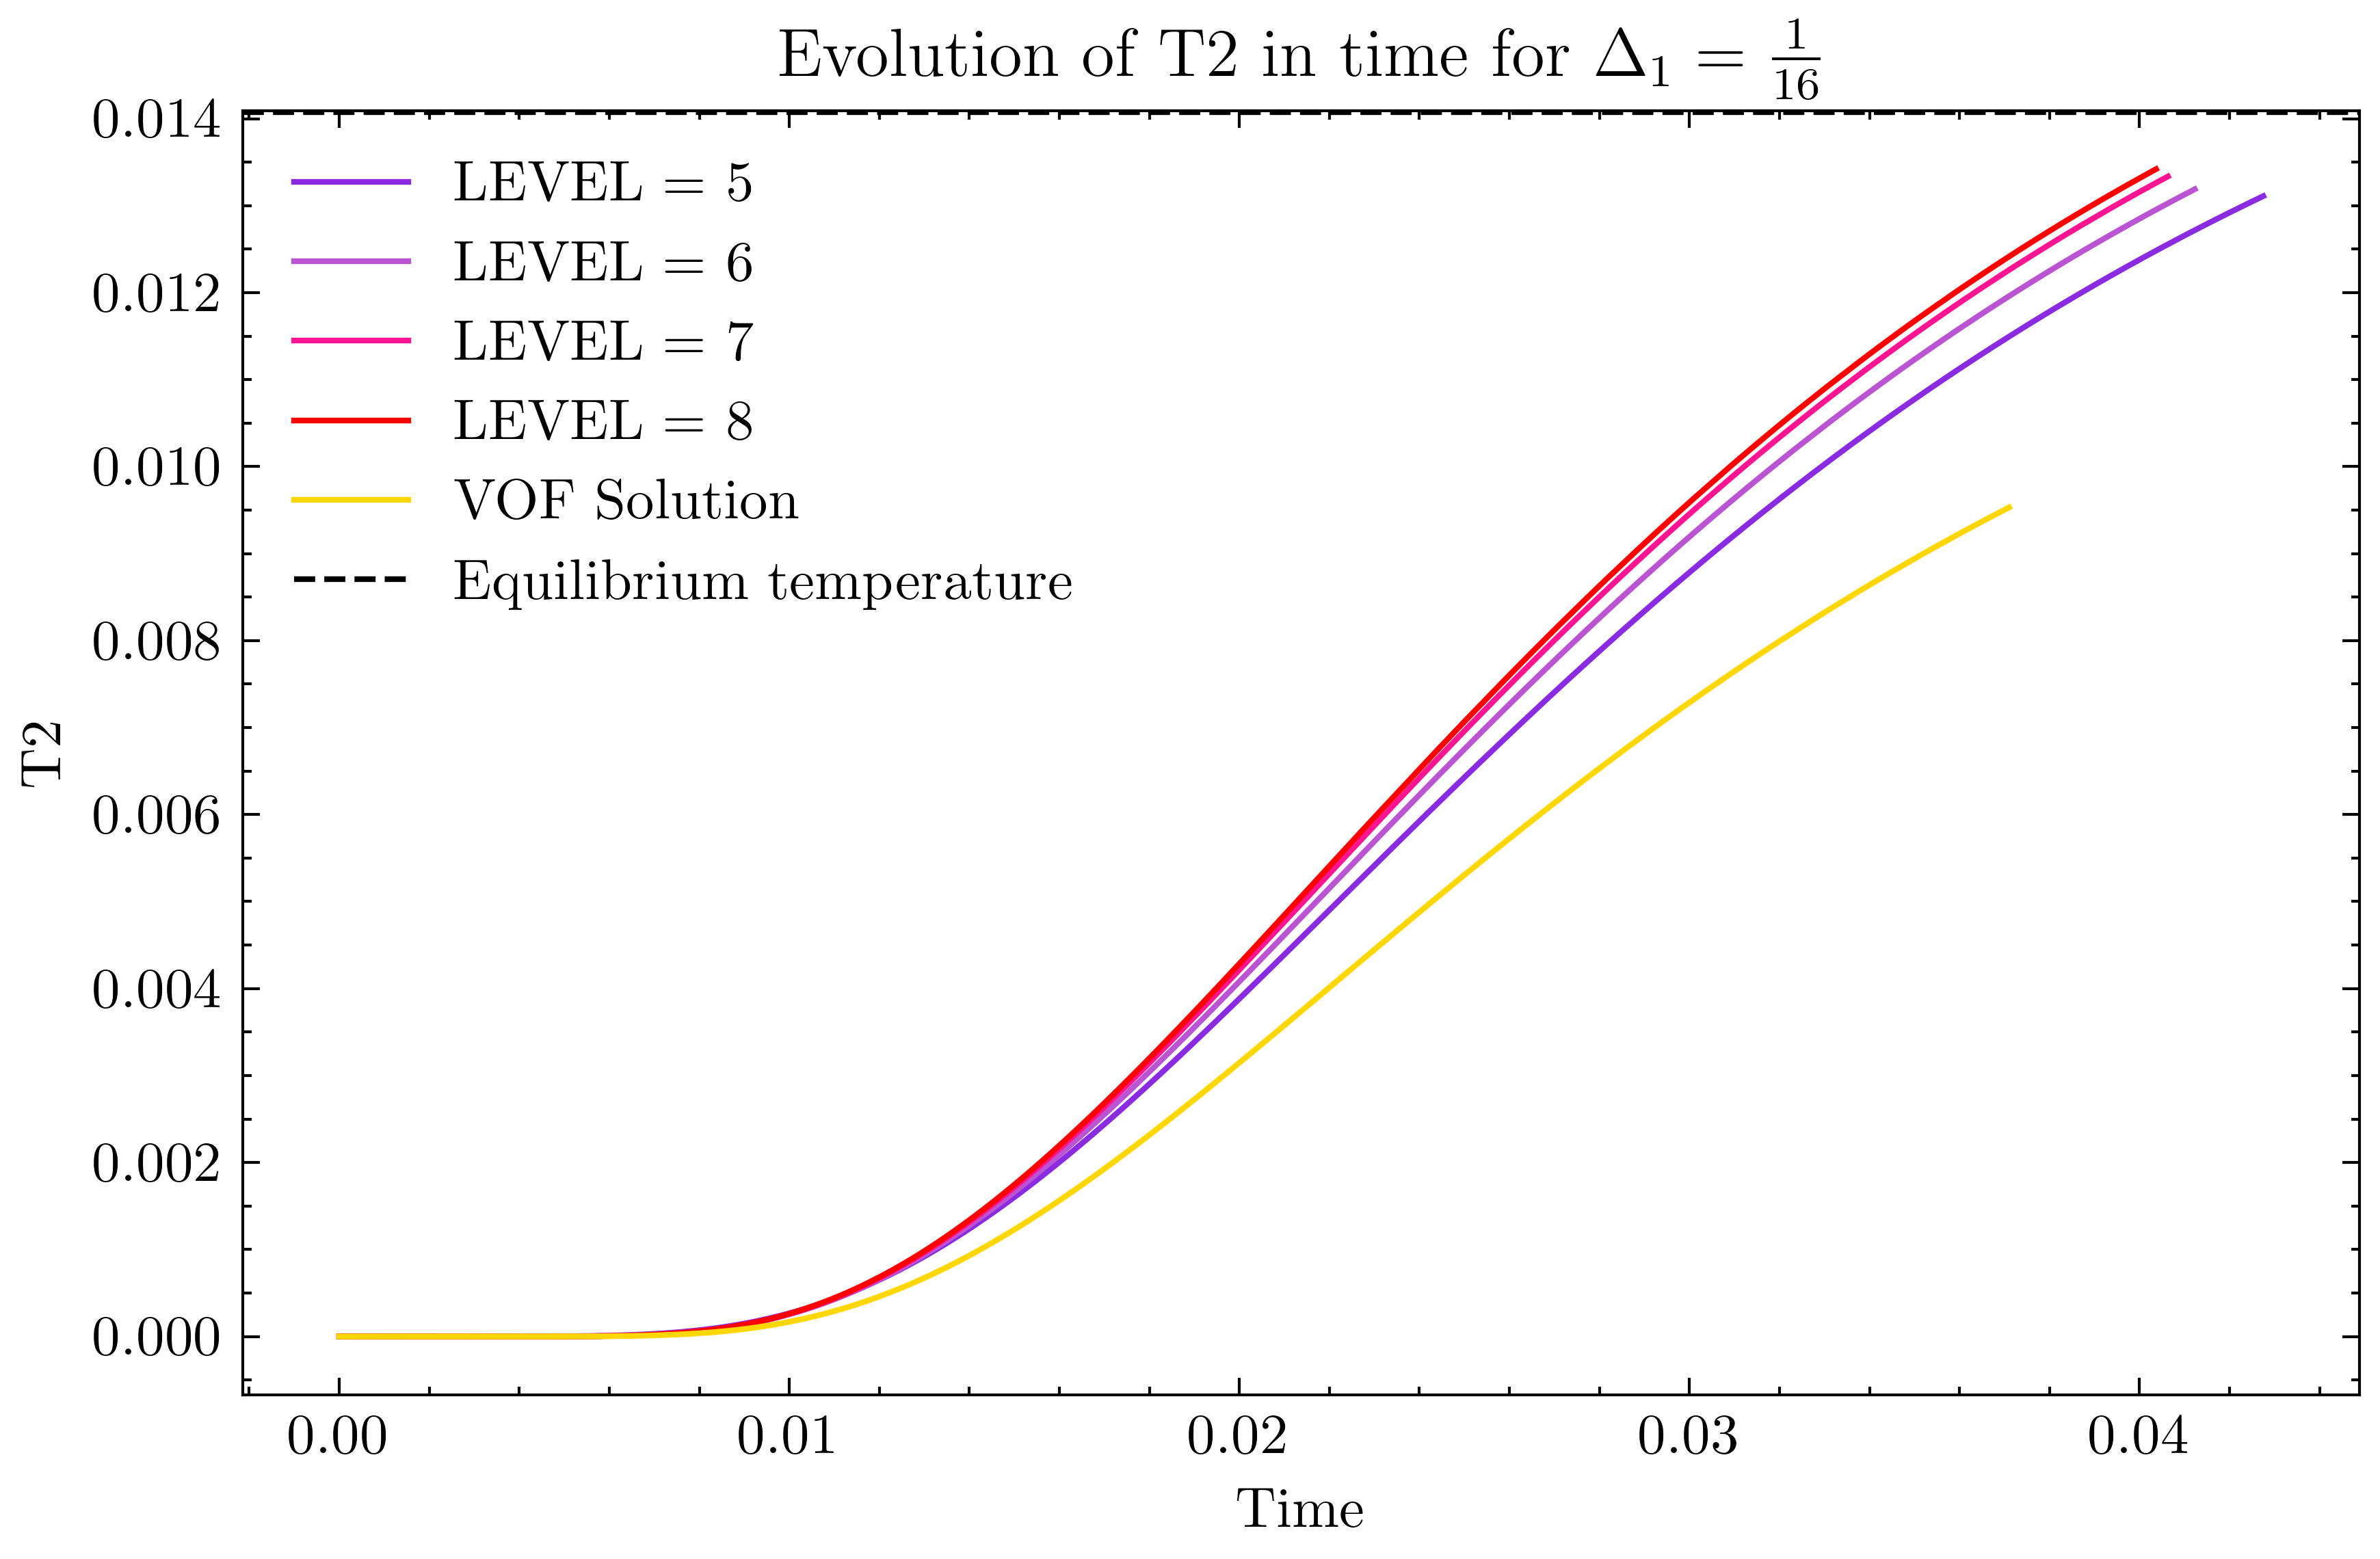

In [3]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)
ax.set_xlabel("Time")
ax.set_ylabel("T2")
ax.set_title(r"Evolution of T2 in time for $\Delta_1 = \frac{1}{16}$")

for i in range(5,9):
    data = np.loadtxt(f"deltax=16/LEVEL_{i}/data.vof")
    time = data[:,0]
    T2 = data[:,2]
    graph_color = cmap(norm(i))
    ax.plot(time, T2, color = graph_color, label = f"LEVEL = {i}")

ax.plot(time_vof,T2_vof, color = "gold", label = "VOF Solution")

plt.axhline(y=eq_temp, color='k', linestyle='--', label = "Equilibrium temperature")
ax.legend()
plt.tight_layout()
plt.savefig("Figures/Error of T2 in time for deltax=16.png",dpi=600)
plt.show()

In [4]:
erreur_T1 = [[] for _ in range(4)]

for i in range(4,8):
    for j in range(i+1,9):
        data_j = np.loadtxt(f"deltax={2**i}/LEVEL_{j}/data.vof")
        t_j = data_j[:, 0]
        T1_j = data_j[:, 1]
        T1_j_interp = np.interp(time_vof, t_j, T1_j)
        erreur_T1_j = np.abs(T1_j_interp - T1_vof)
        erreur_T1[j-5].append(np.mean(np.abs(erreur_T1_j)))

In [5]:
erreur_T2 = [[] for _ in range(4)]

for i in range(4,8):
    for j in range(i+1,9):
        data_j = np.loadtxt(f"deltax={2**i}/LEVEL_{j}/data.vof")
        t_j = data_j[:, 0]
        T2_j = data_j[:, 2]
        T2_j_interp = np.interp(time_vof, t_j, T2_j)
        erreur_T2_j = np.abs(T2_j_interp - T2_vof)
        erreur_T2[j-5].append(np.mean(np.abs(erreur_T2_j)))

/tmp/ipykernel_58765/2468325622.py:14: RankWarning: Polyfit may be poorly conditioned
  power1 = np.polyfit(np.log(delta1[:i+1]), np.log(erreur_T1[i]), deg = 1)[0]
/tmp/ipykernel_58765/2468325622.py:15: RankWarning: Polyfit may be poorly conditioned
  power2 = np.polyfit(np.log(delta1[:i+1]), np.log(erreur_T2[i]), deg = 1)[0]


p1 = 0.78 for T1 and p2 = 1.30 for T2 at LEVEL = 5 
p1 = 0.90 for T1 and p2 = 1.65 for T2 at LEVEL = 6 
p1 = 1.04 for T1 and p2 = 1.46 for T2 at LEVEL = 7 
p1 = 1.17 for T1 and p2 = 1.35 for T2 at LEVEL = 8 


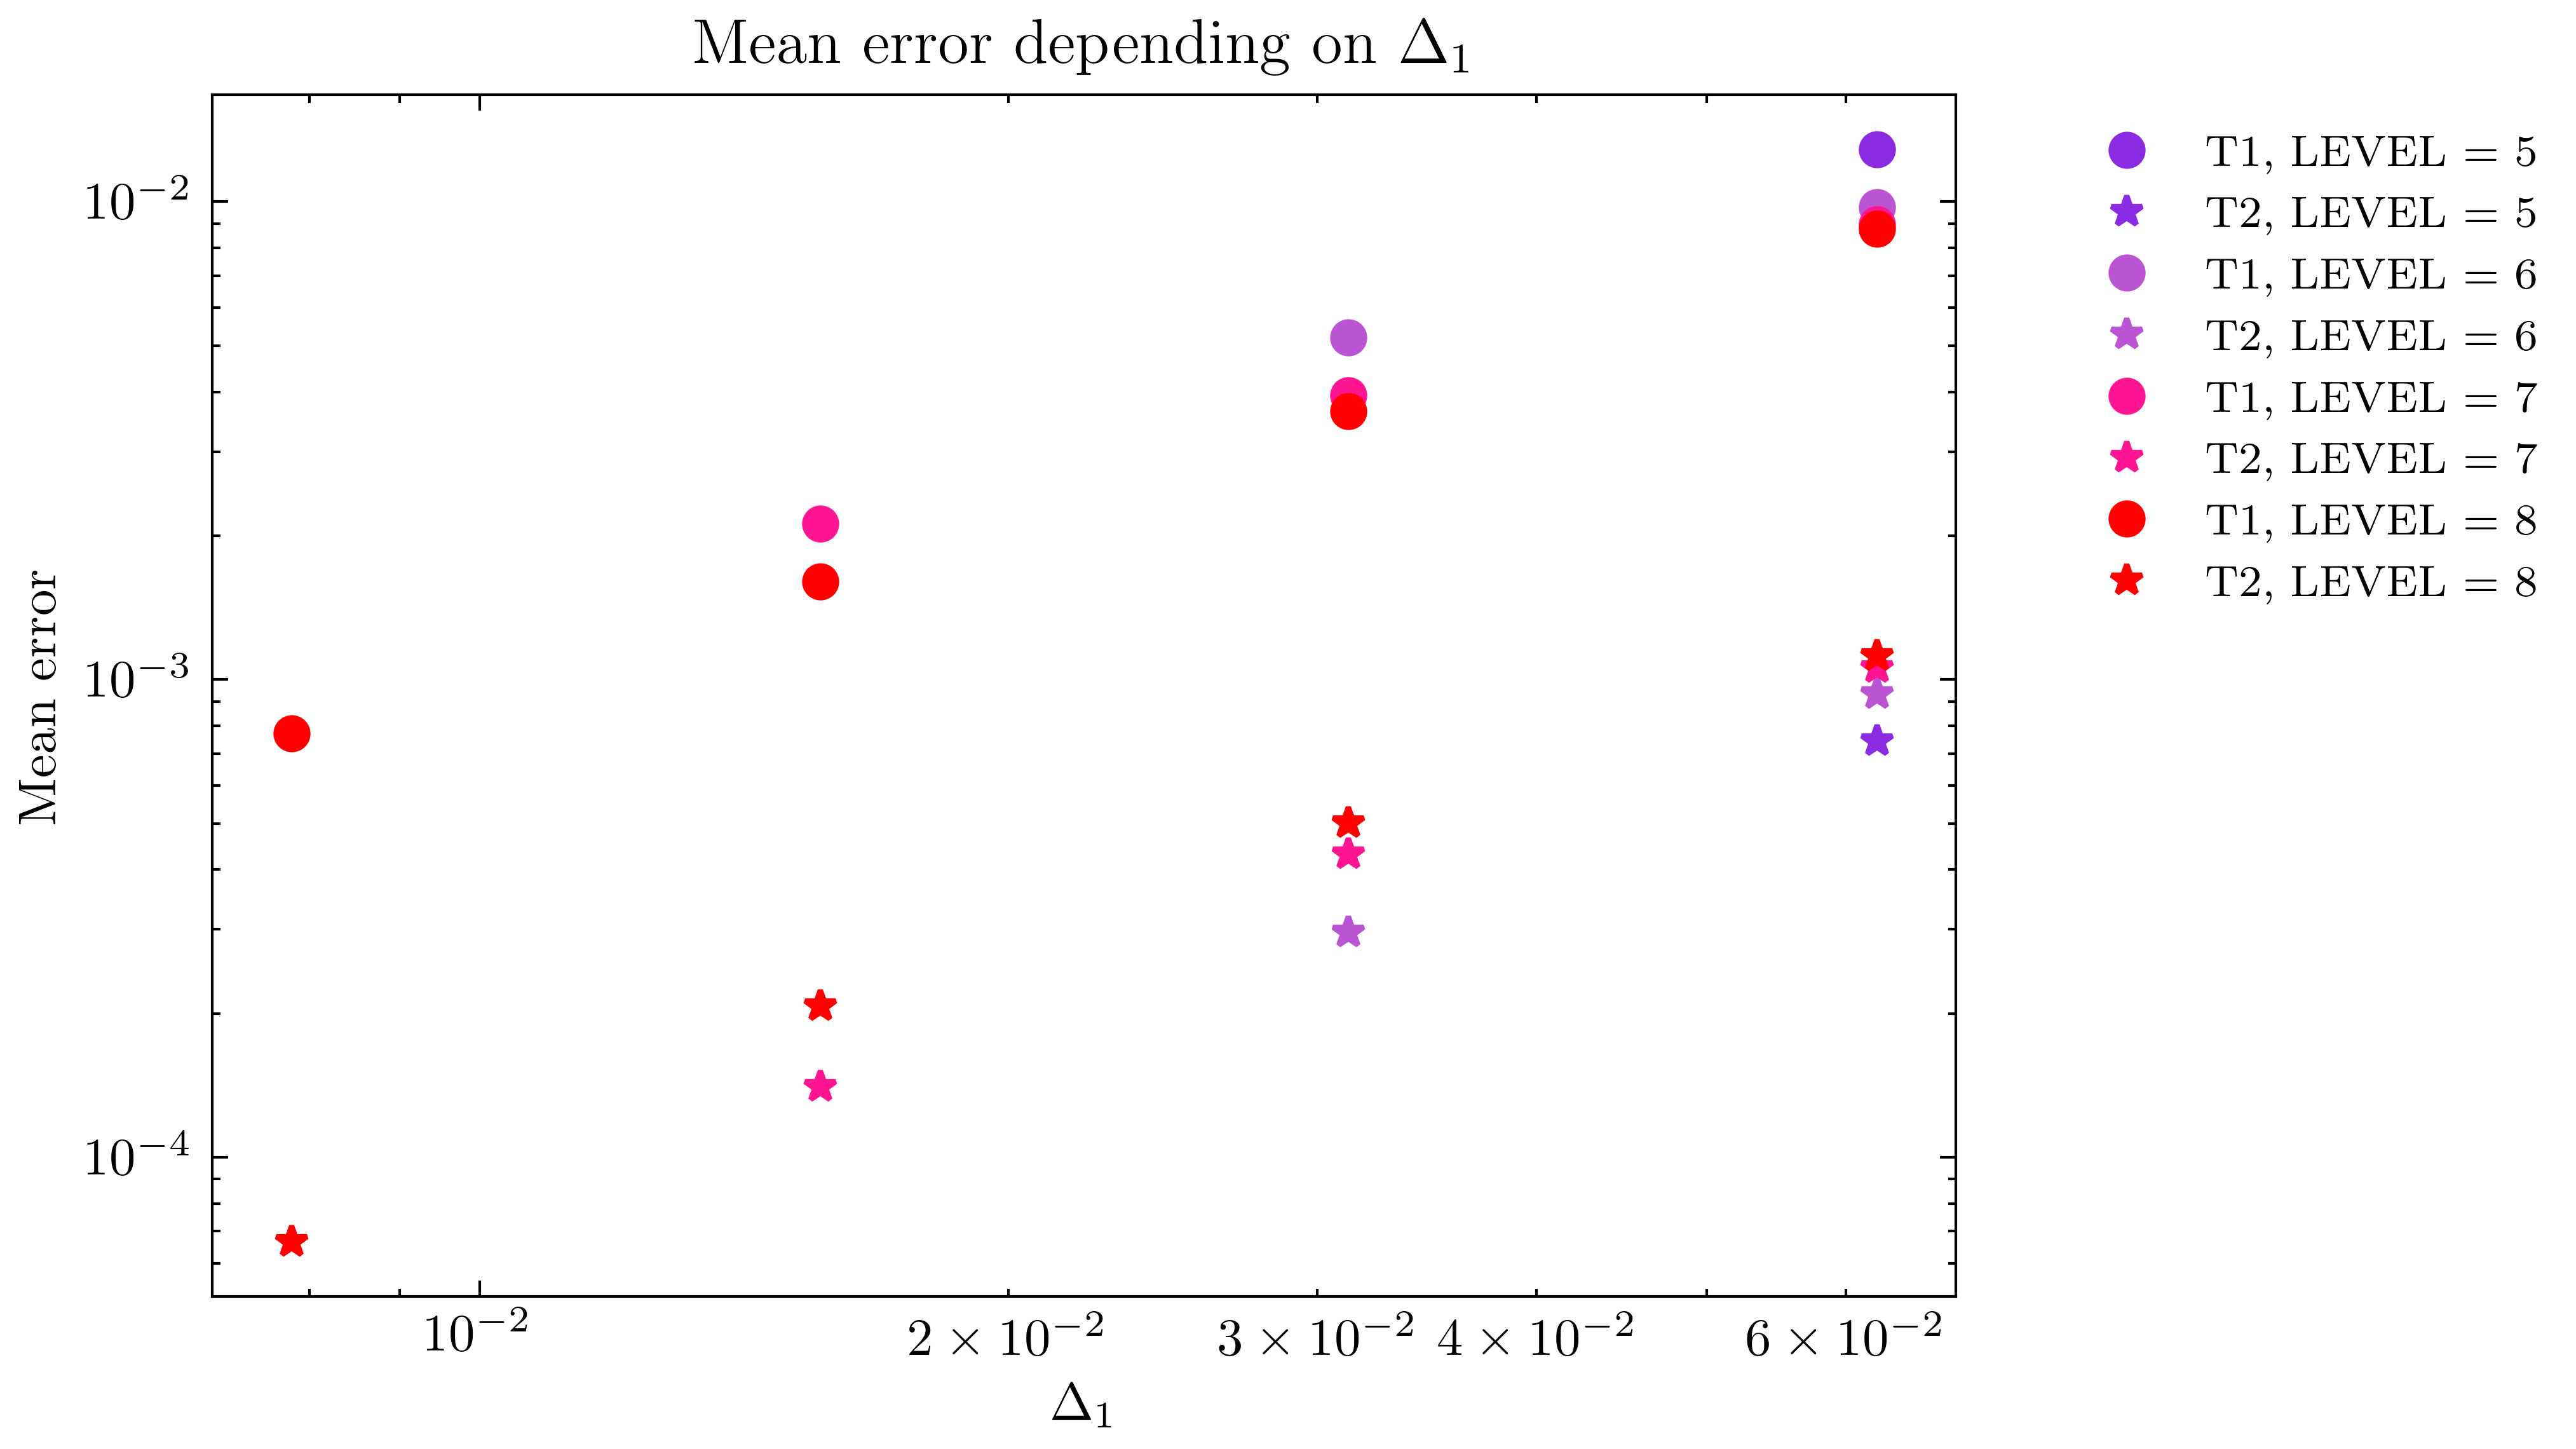

In [6]:
delta1 = np.array([2**(-4),2**(-5),2**(-6),2**(-7)])

fig, ax = plt.subplots(figsize=(7, 4), dpi=600)
ax.set_xlabel(r"$\Delta_1$")
ax.set_ylabel("Mean error")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_title(r"Mean error depending on $\Delta_1$")

for i in range(4):
    graph_color = cmap(norm(5+i))
    ax.plot(delta1[:i+1],erreur_T1[i], 'o', color = graph_color, label=f"T1, LEVEL = {i+5}")
    ax.plot(delta1[:i+1],erreur_T2[i], '*',color = graph_color, label=f"T2, LEVEL = {i+5}")
    power1 = np.polyfit(np.log(delta1[:i+1]), np.log(erreur_T1[i]), deg = 1)[0]
    power2 = np.polyfit(np.log(delta1[:i+1]), np.log(erreur_T2[i]), deg = 1)[0]
    print(f"p1 = {power1:.2f} for T1 and p2 = {power2:.2f} for T2 at LEVEL = {i+5} ")

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.savefig("Figures/Mean error depending on Delta_1.png",dpi=600,bbox_inches='tight')
plt.show()